# Spectral estimation Lab

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import scipy.signal
import statsmodels.api as sm
import os
import zipfile
import soundfile as sf

## 1. Autoregressive process

### 1.1 Synthesis

1. Code a function that synthesizes an autoregressive (AR) process of length N, defined by its AR coefficients and the innovation variance $\sigma^2$

In [3]:
def synthetize_AR(N, ARCoefficients, sigma2=1):
    """
    Synthesizes an autoregressive (AR) process of length N,
    defined by its ARcoefficients and the innovation variance σ^2
    """
    ARCoefficients = np.array(ARCoefficients)
    p = len(ARCoefficients)
    signal = np.zeros(N)
    noise = np.random.normal(0, np.sqrt(sigma2), N)
    for n in range(p,N):
        signal[n] = np.dot(ARCoefficients, signal[n-p:n][::-1]) + noise[n]
    return signal

print(synthetize_AR(30, [0.5, -0.3], sigma2=1))

[ 0.          0.         -0.41677418  0.37149882  2.61487598  2.03141297
  0.99431565 -0.68394611 -2.28475726  0.42121573  0.96885189 -0.92082723
 -0.99452347 -1.47254223 -0.53885543 -0.21500545  0.79985669  0.47179628
 -1.69350091 -1.51261059 -0.37845954 -0.64533804 -1.30579198 -1.09141692
  1.03446271 -0.50871008  0.05543844  1.27074267  2.06150194  0.14695467]


### 1.2 Non-parametric estimation : periodogram

2. Code a function that computes and displays the periodogram of a given input signal, allowing to choose between the standard method and the Bartlett and Welsh methods.

In [44]:
def periodogram(signal, method='standard', bartlett_L=None, welch_S=None, welch_K=None,
                durbin_p=None, durbin_q=None):
    """
    Computes the periodogram of a given input signal, allowing to
    choose between the standard ('standard') method and the Bartlett ('bartlett'),
    Welch ('welch'), Capon ('capon'), and Durbin ('durbin') methods.
    """

    if method not in ["standard", "bartlett", "welch", "capon", "durbin"]:
        raise ValueError("Invalid method. Choose 'standard', 'bartlett', 'welch', 'capon', or 'durbin'.")

    if method == 'standard':
        def standard(nu):
            N = len(signal)
            return 1/N * abs(np.sum(signal * np.exp(-2j * np.pi * nu * np.arange(N))))**2
        return standard
    
    elif method == 'bartlett':
        def bartlett(nu):
            N = len(signal)
            L = bartlett_L if bartlett_L is not None else int(N / 4)
            M = int(N/L)
            S_B = 0
            for i in range(L):
                X_tilde = signal[i * M : (i + 1) * M]
                t = np.arange(1, M + 1)
                periodogram_i = (1 / M) * np.abs(np.sum(X_tilde * np.exp(-2j * np.pi * nu * t)))**2
                S_B += periodogram_i
                
            return S_B / L
        return bartlett
    
    elif method == 'welch':
        def welch(nu):
            N = len(signal)
            M = int(N / 4)
            K = int(M / 2) 
            S = int((N - M) / K) + 1
            v = np.hamming(M)
            
            P = (1 / M) * np.sum(np.abs(v)**2)
            
            S_W = 0
            for i in range(1, S + 1):
                start = (i - 1) * K
                X_tilde = signal[start : start + M]
                t = np.arange(1, M + 1)
                periodogram_i = (1 / (M * P)) * np.abs(np.sum(v * X_tilde * np.exp(-2j * np.pi * nu * t)))**2
                S_W += periodogram_i
                
            return S_W / S
            
        return welch
    
    elif method == 'capon':
        N_sig = len(signal)
        M = min(N_sig // 4, 128)
        L = N_sig - M + 1
        X = np.array([signal[i:i+M] for i in range(L)])
        R = (X.T @ X) / L
        R += 1e-10 * np.eye(M)
        R_inv = np.linalg.inv(R)

        def capon(nu):
            e = np.exp(2j * np.pi * nu * np.arange(M))
            return float(np.real(M / (e.conj().T @ R_inv @ e)))
        return capon

    elif method == 'durbin':
        # Durbin method for ARMA(p,q) spectral estimation
        p = durbin_p if durbin_p is not None else 1
        q = durbin_q if durbin_q is not None else 1
        N_sig = len(signal)

        # Step 1: Estimate autocorrelation
        r = np.correlate(signal, signal, 'full') / N_sig
        r = r[N_sig - 1:]  # positive lags r[0], r[1], ...

        # Step 2: Modified Yule-Walker for AR coefficients
        # r[k] = a1*r[k-1] + ... + ap*r[k-p]  for k > q
        R_mat = np.zeros((p, p))
        r_vec = np.zeros(p)
        for i in range(p):
            r_vec[i] = r[q + 1 + i]
            for j in range(p):
                R_mat[i, j] = r[abs(q + i - j)]
        ar_hat = np.linalg.solve(R_mat, r_vec)

        # AR polynomial A(z) = 1 - a1 z^-1 - ... - ap z^-p
        A_poly = np.concatenate(([1.0], -ar_hat))

        # Step 3: Filter signal through AR part to get approx. MA process
        w = scipy.signal.lfilter(A_poly, [1.0], signal)

        # Step 4: Fit a long AR to w, then extract MA via impulse response
        L_long = min(max(10 * q, 30), N_sig // 4)
        long_ar_w = librosa.lpc(w[p:].astype(np.float64), order=L_long)
        impulse = np.zeros(q + 1)
        impulse[0] = 1.0
        ma_hat = scipy.signal.lfilter([1.0], long_ar_w, impulse)

        # Step 5: Estimate innovation variance
        residual = scipy.signal.lfilter(A_poly, ma_hat, signal)
        sigma2_hat = np.var(residual[max(p, q):])

        # Pre-compute index vectors
        k_a = np.arange(len(A_poly))
        k_b = np.arange(len(ma_hat))

        def durbin_func(nu):
            A_nu = np.sum(A_poly * np.exp(-2j * np.pi * nu * k_a))
            B_nu = np.sum(ma_hat * np.exp(-2j * np.pi * nu * k_b))
            return float(sigma2_hat * np.abs(B_nu)**2 / (np.abs(A_nu)**2 + 1e-12))
        return durbin_func


def show_periodogram(signal, resolution=1e-3, methods=['standard'], bartlett_L=None, welch_S=None, welch_K=None):
    """
    Displays the periodogram of the process using the chosen method(s).
    Choose between the standard ('standard') method, the Bartlett ('bartlett'), Welch ('welch'), and Capon ('capon') methods.
    """
    nu_values = np.arange(0, 0.5, resolution)
    plt.figure(figsize=(10, 6))
    
    for method in methods:
        if method not in ["standard", "bartlett", "welch", "capon"]:
            raise ValueError(f"Invalid method '{method}'. Choose 'standard', 'bartlett', 'welch', or 'capon'.")
        
        periodogram_func = periodogram(signal, method, bartlett_L=bartlett_L, welch_S=welch_S, welch_K=welch_K)
        periodogram_values = [periodogram_func(nu) for nu in nu_values]
        plt.plot(nu_values, periodogram_values, label=method.capitalize())
        
    plt.xlabel('Frequency')
    plt.ylabel('Power')
    plt.title('Periodogram Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

3. Display the periodograms obtained with the different methods (in dB), in the case of an AR process of order 1 whose parameters can be chosen by hand. We will superimpose in each case the periodogram with the known power spectral density (PSD) of the AR process. We will pay attention to the correct normalization of the different estimators.

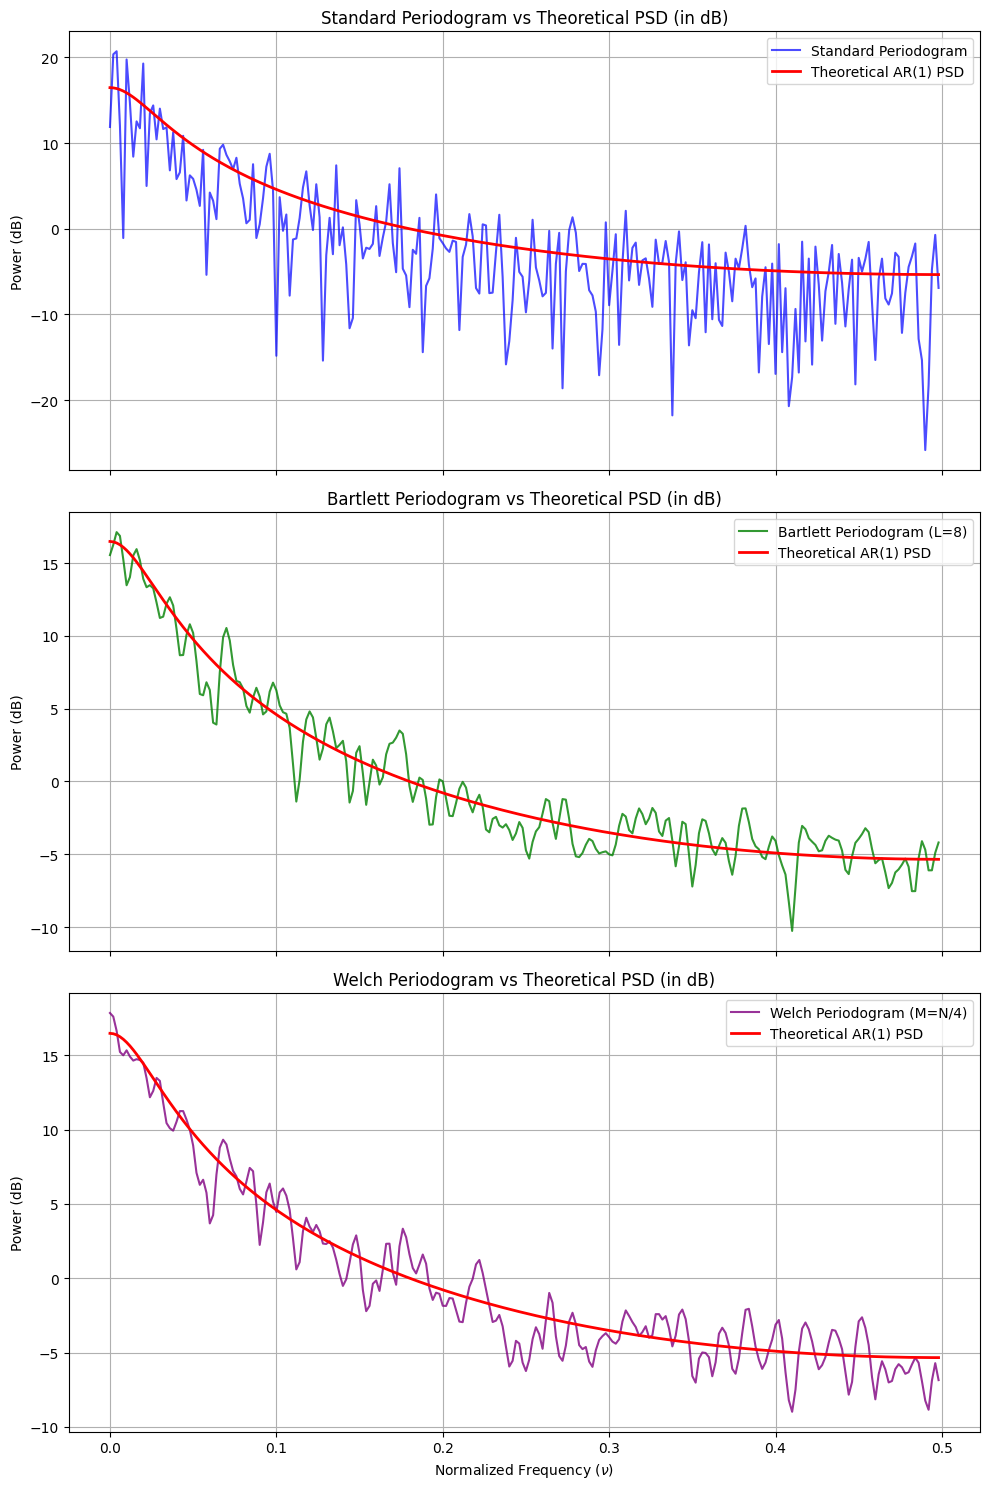

In [5]:
N = 1000
np.random.seed(42)

variance_noise = 1.0
noise = np.random.normal(0, np.sqrt(variance_noise), N)
signal = np.zeros(N)

a = 0.85 

for t in range(1, N):
    signal[t] = a * signal[t-1] + noise[t]

nu_values = np.arange(0, 0.5, 0.002)

theoretical_psd = variance_noise / np.abs(1 - a * np.exp(-2j * np.pi * nu_values))**2

theoretical_psd_db = 10 * np.log10(theoretical_psd)

std_periodogram = periodogram(signal, 'standard')
bart_periodogram = periodogram(signal, 'bartlett', bartlett_L=8)
welch_periodogram = periodogram(signal, 'welch')

p_std = np.array([std_periodogram(nu) for nu in nu_values])
p_bar = np.array([bart_periodogram(nu) for nu in nu_values])
p_wel = np.array([welch_periodogram(nu) for nu in nu_values])

p_std_db = 10 * np.log10(p_std)
p_bar_db = 10 * np.log10(p_bar)
p_wel_db = 10 * np.log10(p_wel)

fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

axs[0].plot(nu_values, p_std_db, label='Standard Periodogram', color='blue', alpha=0.7)
axs[0].plot(nu_values, theoretical_psd_db, label='Theoretical AR(1) PSD', color='red', linewidth=2)
axs[0].set_title('Standard Periodogram vs Theoretical PSD (in dB)')
axs[0].set_ylabel('Power (dB)')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(nu_values, p_bar_db, label='Bartlett Periodogram (L=8)', color='green', alpha=0.8)
axs[1].plot(nu_values, theoretical_psd_db, label='Theoretical AR(1) PSD', color='red', linewidth=2)
axs[1].set_title('Bartlett Periodogram vs Theoretical PSD (in dB)')
axs[1].set_ylabel('Power (dB)')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(nu_values, p_wel_db, label='Welch Periodogram (M=N/4)', color='purple', alpha=0.8)
axs[2].plot(nu_values, theoretical_psd_db, label='Theoretical AR(1) PSD', color='red', linewidth=2)
axs[2].set_title('Welch Periodogram vs Theoretical PSD (in dB)')
axs[2].set_xlabel('Normalized Frequency ($\\nu$)')
axs[2].set_ylabel('Power (dB)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

4. Experimentally compare these different estimators in terms of bias and variance

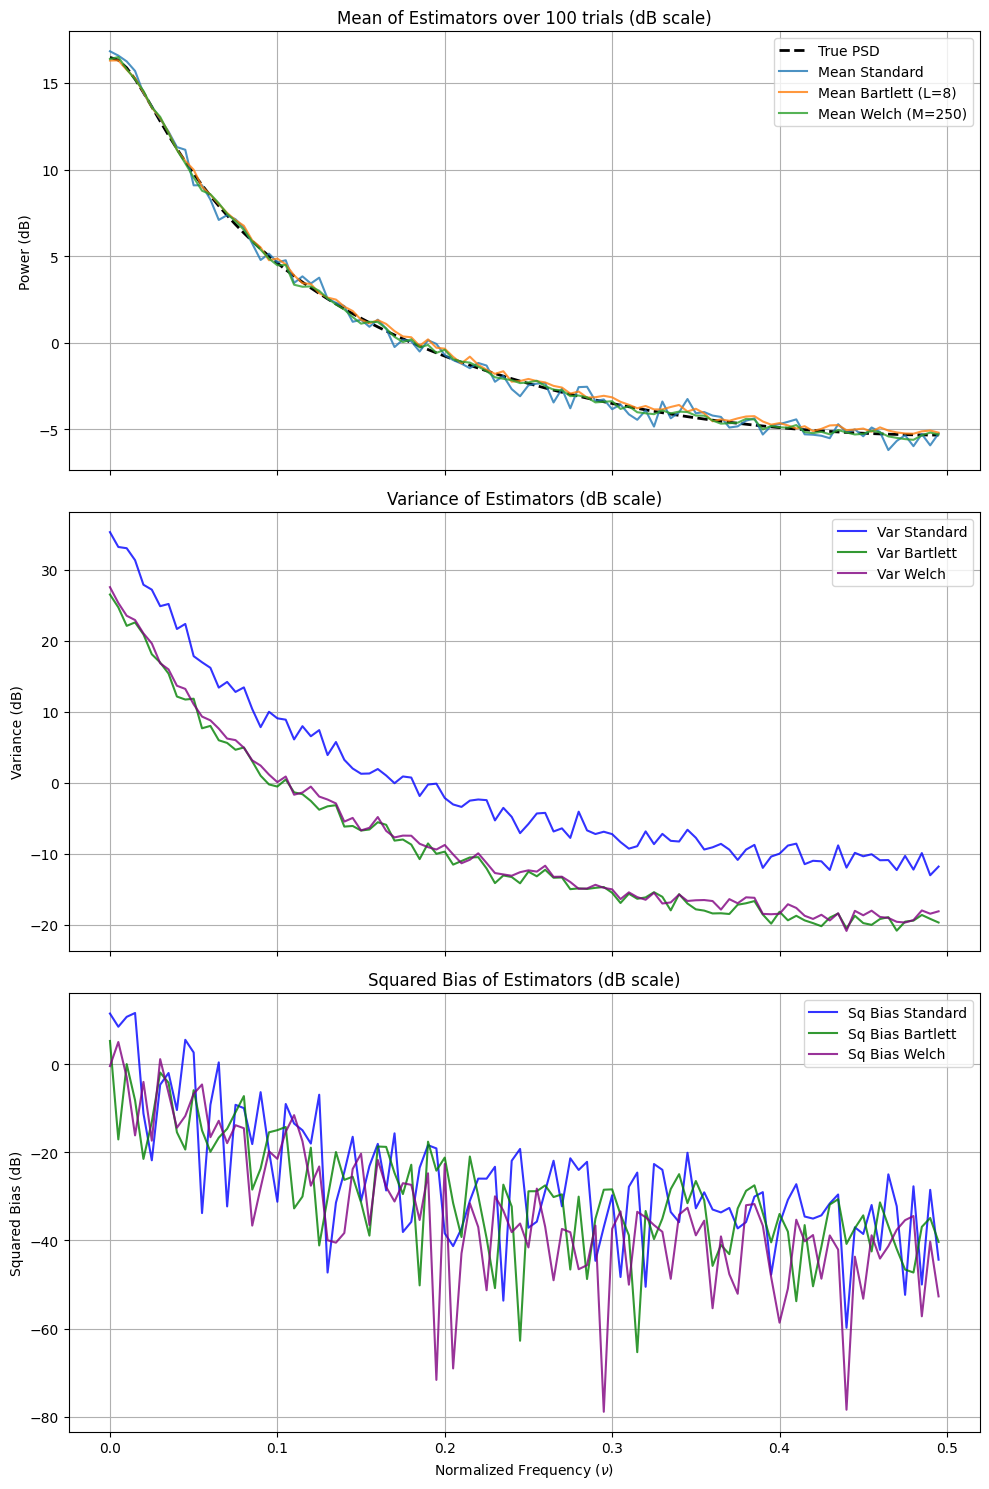

In [6]:
N = 1000
a = 0.85
variance_noise = 1.0
num_trials = 100
nu_values = np.arange(0, 0.5, 0.005)

theoretical_psd = variance_noise / np.abs(1 - a * np.exp(-2j * np.pi * nu_values))**2

std_estimates = np.zeros((num_trials, len(nu_values)))
bar_estimates = np.zeros((num_trials, len(nu_values)))
wel_estimates = np.zeros((num_trials, len(nu_values)))

np.random.seed(42)

for k in range(num_trials):
    noise = np.random.normal(0, np.sqrt(variance_noise), N)
    signal = np.zeros(N)
    for t in range(1, N):
        signal[t] = a * signal[t-1] + noise[t]
        
    std_func = periodogram(signal, 'standard')
    bar_func = periodogram(signal, 'bartlett', bartlett_L=8)
    wel_func = periodogram(signal, 'welch')
    
    std_estimates[k, :] = [std_func(nu) for nu in nu_values]
    bar_estimates[k, :] = [bar_func(nu) for nu in nu_values]
    wel_estimates[k, :] = [wel_func(nu) for nu in nu_values]

mean_std = np.mean(std_estimates, axis=0)
mean_bar = np.mean(bar_estimates, axis=0)
mean_wel = np.mean(wel_estimates, axis=0)

var_std = np.var(std_estimates, axis=0)
var_bar = np.var(bar_estimates, axis=0)
var_wel = np.var(wel_estimates, axis=0)

sq_bias_std = (mean_std - theoretical_psd)**2
sq_bias_bar = (mean_bar - theoretical_psd)**2
sq_bias_wel = (mean_wel - theoretical_psd)**2

fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

axs[0].plot(nu_values, 10*np.log10(theoretical_psd), 'k--', label='True PSD', linewidth=2)
axs[0].plot(nu_values, 10*np.log10(mean_std), label='Mean Standard', alpha=0.8)
axs[0].plot(nu_values, 10*np.log10(mean_bar), label='Mean Bartlett (L=8)', alpha=0.8)
axs[0].plot(nu_values, 10*np.log10(mean_wel), label='Mean Welch (M=250)', alpha=0.8)
axs[0].set_title('Mean of Estimators over 100 trials (dB scale)')
axs[0].set_ylabel('Power (dB)')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(nu_values, 10*np.log10(var_std), label='Var Standard', color='blue', alpha=0.8)
axs[1].plot(nu_values, 10*np.log10(var_bar), label='Var Bartlett', color='green', alpha=0.8)
axs[1].plot(nu_values, 10*np.log10(var_wel), label='Var Welch', color='purple', alpha=0.8)
axs[1].set_title('Variance of Estimators (dB scale)')
axs[1].set_ylabel('Variance (dB)')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(nu_values, 10*np.log10(sq_bias_std + 1e-12), label='Sq Bias Standard', color='blue', alpha=0.8)
axs[2].plot(nu_values, 10*np.log10(sq_bias_bar + 1e-12), label='Sq Bias Bartlett', color='green', alpha=0.8)
axs[2].plot(nu_values, 10*np.log10(sq_bias_wel + 1e-12), label='Sq Bias Welch', color='purple', alpha=0.8)
axs[2].set_title('Squared Bias of Estimators (dB scale)')
axs[2].set_xlabel('Normalized Frequency ($\\nu$)')
axs[2].set_ylabel('Squared Bias (dB)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

### 1.3 Parametric estimation : linear prediction

5. Estimate the AR model using either the code you wrote in the previous practical work of 4AI02, or the function lpc (linear prediction method) from Matlab or from the librosa Python package

True AR parameter (a): 0.85
Estimated AR parameter (a_hat): 0.8490
True Noise Variance: 1.0
Estimated Noise Variance: 0.9577


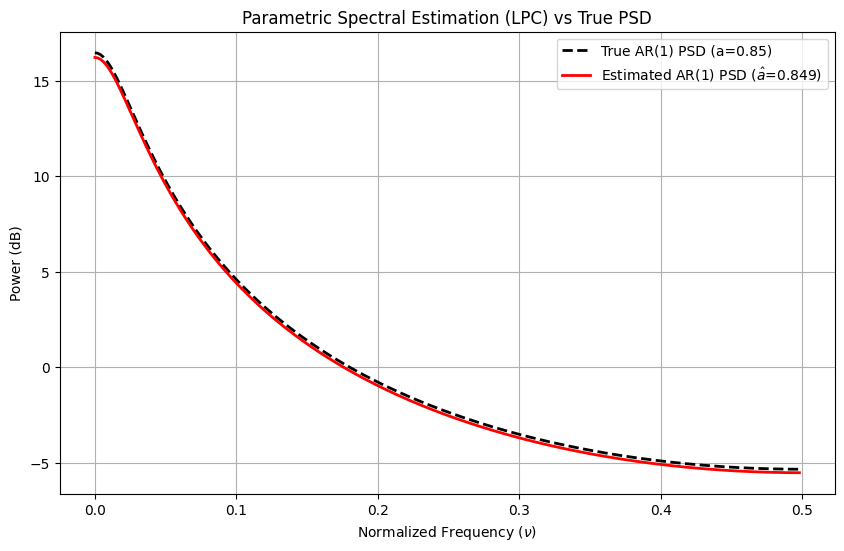

In [7]:
N = 1000
np.random.seed(42)
variance_noise = 1.0
noise = np.random.normal(0, np.sqrt(variance_noise), N)
signal = np.zeros(N)

# True parameter
a_true = 0.85 

for t in range(1, N):
    signal[t] = a_true * signal[t-1] + noise[t]

lpc_coeffs = librosa.lpc(signal, order=1)

a_hat = -lpc_coeffs[1]

residual = scipy.signal.lfilter(lpc_coeffs, [1], signal)
variance_noise_hat = np.var(residual)

print(f"True AR parameter (a): {a_true}")
print(f"Estimated AR parameter (a_hat): {a_hat:.4f}")
print(f"True Noise Variance: {variance_noise}")
print(f"Estimated Noise Variance: {variance_noise_hat:.4f}")

nu_values = np.arange(0, 0.5, 0.002)

theoretical_psd = variance_noise / np.abs(1 - a_true * np.exp(-2j * np.pi * nu_values))**2
theoretical_psd_db = 10 * np.log10(theoretical_psd)

estimated_psd = variance_noise_hat / np.abs(1 - a_hat * np.exp(-2j * np.pi * nu_values))**2
estimated_psd_db = 10 * np.log10(estimated_psd)


plt.figure(figsize=(10, 6))
plt.plot(nu_values, theoretical_psd_db, 'k--', label=f'True AR(1) PSD (a={a_true})', linewidth=2)
plt.plot(nu_values, estimated_psd_db, 'r-', label=f'Estimated AR(1) PSD ($\\hat{{a}}$={a_hat:.3f})', linewidth=2)

plt.title('Parametric Spectral Estimation (LPC) vs True PSD')
plt.xlabel('Normalized Frequency ($\\nu$)')
plt.ylabel('Power (dB)')
plt.legend()
plt.grid(True)
plt.show()

6. Superimpose the spectral envelope of the estimated AR model with that of the exact AR model and with the periodogram. Comment.

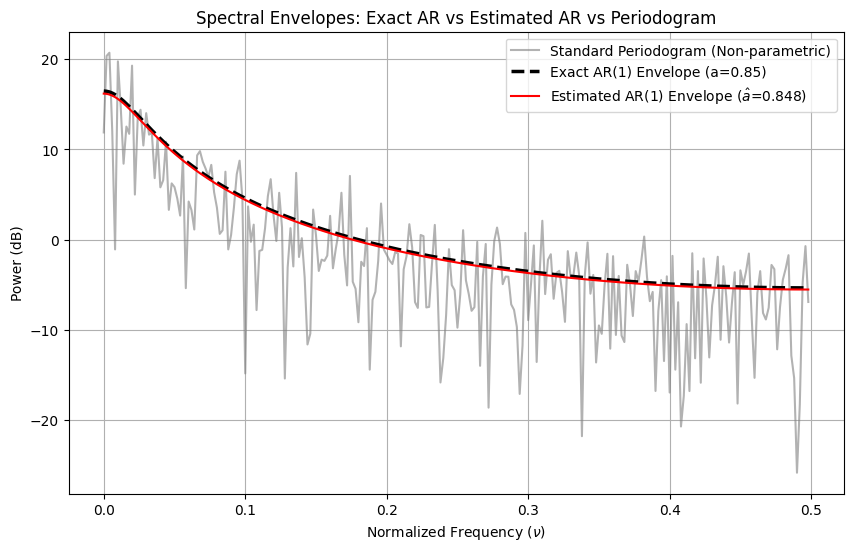

In [8]:
N = 1000
np.random.seed(42)
variance_noise = 1.0
noise = np.random.normal(0, np.sqrt(variance_noise), N)
signal = np.zeros(N)
a = 0.85 
for t in range(1, N):
    signal[t] = a * signal[t-1] + noise[t]

def standard_periodogram(nu):
    return 1/N * np.abs(np.sum(signal * np.exp(-2j * np.pi * nu * np.arange(N))))**2

nu_values = np.arange(0, 0.5, 0.002)
p_std = np.array([standard_periodogram(nu) for nu in nu_values])
p_std_db = 10 * np.log10(p_std)

theoretical_psd = variance_noise / np.abs(1 - a * np.exp(-2j * np.pi * nu_values))**2
theoretical_psd_db = 10 * np.log10(theoretical_psd)

r = sm.tsa.acf(signal, nlags=1)
a_hat = r[1]
var_signal = np.var(signal)
variance_noise_hat = var_signal * (1 - a_hat**2)

estimated_psd = variance_noise_hat / np.abs(1 - a_hat * np.exp(-2j * np.pi * nu_values))**2
estimated_psd_db = 10 * np.log10(estimated_psd)

plt.figure(figsize=(10, 6))
plt.plot(nu_values, p_std_db, color='gray', alpha=0.6, label='Standard Periodogram (Non-parametric)')
plt.plot(nu_values, theoretical_psd_db, 'k--', linewidth=2.5, label=f'Exact AR(1) Envelope (a={a})')
plt.plot(nu_values, estimated_psd_db, 'r-', linewidth=1.5, label=f'Estimated AR(1) Envelope ($\\hat{{a}}$={a_hat:.3f})')

plt.title('Spectral Envelopes: Exact AR vs Estimated AR vs Periodogram')
plt.xlabel('Normalized Frequency ($\\nu$)')
plt.ylabel('Power (dB)')
plt.legend()
plt.grid(True)
plt.show()

**Answer :**

Unlike the highly noisy non-parametric periodogram, the parametric AR model accurately and smoothly captures the true spectral envelope by leveraging the underlying structure of the signal.

### 1.4 Application to speech signals

7. Apply the above methods to a vowel sound (such as ’a’ for example, that we can extract from file aeiou.wav, downloadable from the IP Paris Moodle of 4AI03), and superimpose the estimated spectra. Comment.

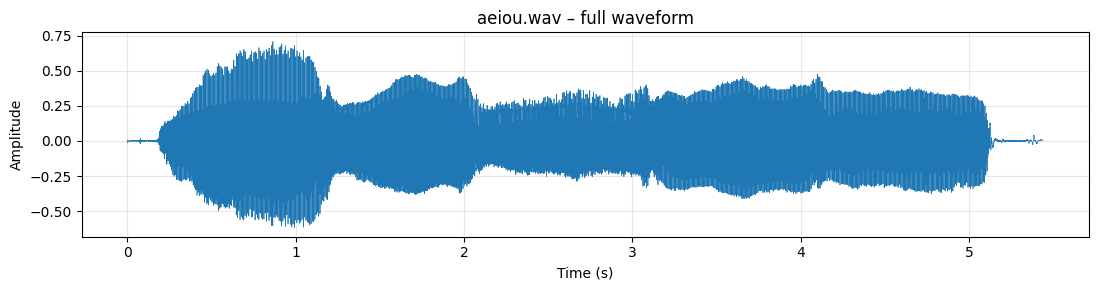

Sampling rate: 11025 Hz | Duration: 5.44 s


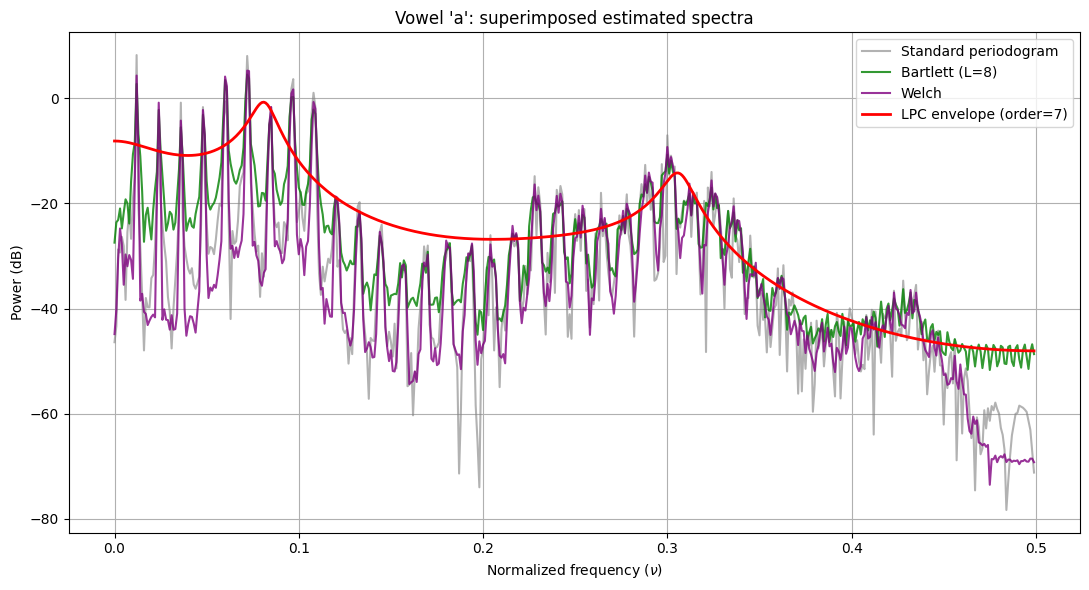

Extracted segment length: 0.550 s


In [51]:

# Load the vowel recording and keep a mono signal
audio_path = "aeiou.wav"
signal_speech, sr = sf.read(audio_path)
if signal_speech.ndim > 1:
    signal_speech = signal_speech.mean(axis=1)

# Plot the full waveform to identify the 'a' segment
plt.figure(figsize=(11, 3))
t_axis = np.arange(len(signal_speech)) / sr
plt.plot(t_axis, signal_speech, linewidth=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('aeiou.wav – full waveform')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Sampling rate: {sr} Hz | Duration: {len(signal_speech)/sr:.2f} s")

# Extract a segment of the vowel 'a'
start_time = 0.5
end_time = 1.05
start_sample = int(start_time * sr)
end_sample = int(end_time * sr)
y_a = signal_speech[start_sample:end_sample]

# Frequency grid
nu_values = np.arange(0, 0.5, 0.001)
eps = 1e-12

# Non-parametric spectra (methods from section 1.2)
p_std = np.array([periodogram(y_a, 'standard')(nu) for nu in nu_values])
p_bar = np.array([periodogram(y_a, 'bartlett', bartlett_L=8)(nu) for nu in nu_values])
p_wel = np.array([periodogram(y_a, 'welch')(nu) for nu in nu_values])

p_std_db = 10 * np.log10(p_std + eps)
p_bar_db = 10 * np.log10(p_bar + eps)
p_wel_db = 10 * np.log10(p_wel + eps)

# Parametric spectrum via LPC (section 1.3)
order = 7
a_lpc = librosa.lpc(y_a, order=order)
residu = scipy.signal.lfilter(a_lpc, [1], y_a)
variance_estimee = np.var(residu)

k = np.arange(order + 1)
A_mu = np.array([np.sum(a_lpc * np.exp(-2j * np.pi * nu * k)) for nu in nu_values])
psd_estimee = variance_estimee / (np.abs(A_mu)**2 + eps)
psd_estimee_dB = 10 * np.log10(psd_estimee + eps)

# Superimposed spectra
plt.figure(figsize=(11, 6))
plt.plot(nu_values, p_std_db, color='gray', alpha=0.6, label='Standard periodogram')
plt.plot(nu_values, p_bar_db, color='green', alpha=0.8, label='Bartlett (L=8)')
plt.plot(nu_values, p_wel_db, color='purple', alpha=0.8, label='Welch')
plt.plot(nu_values, psd_estimee_dB, color='red', linewidth=2.0, label=f'LPC envelope (order={order})')
plt.title("Vowel 'a': superimposed estimated spectra")
plt.xlabel('Normalized frequency ($\\nu$)')
plt.ylabel('Power (dB)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Extracted segment length: {len(y_a)/sr:.3f} s")


**Answer :**

For the extracted vowel segment, the standard periodogram is very irregular (high variance), while Bartlett and Welch are clearly smoother because averaging reduces variance. This smoothing also broadens peaks slightly, so very fine spectral details are less sharp. The LPC estimate provides the smoothest spectral envelope and highlights the main formant regions of the vowel (dominant resonances of the vocal tract), which makes it the most interpretable estimate for speech analysis.

## 2. Sum of noisy sinusoids

### 2.1 Synthesis


1. Code a function that synthesizes a signal of length N, consisting of the sum of K real sinusoids defined by their frequencies, amplitudes and origin phases, and a Gaussian white noise of variance $\sigma^2$

In [10]:
def synthetize_sum_of_sinusoids(frequencies, amplitudes, phases, sigma, N):
    """
    Synthesizes a signal as a sum of sinusoids given their frequencies, amplitudes, and phases.
    """
    if len(frequencies) != len(amplitudes) or len(frequencies) != len(phases):
        raise ValueError("Frequencies, amplitudes, and phases must have the same length.")
    
    t = np.arange(N)
    signal = np.zeros(N)
    for f, A, phi in zip(frequencies, amplitudes, phases):
        signal += A * np.cos(2 * np.pi * f * t / N + phi)
    noise = np.random.normal(0, np.sqrt(sigma), N)
    signal += noise
    return signal

### 2.2 Non parametric estimation : periodogram

2. Display the periodograms obtained with the standard method and the Bartlett and Welsh methods,
in the case of K = 2 sinusoidal frequencies $\nu _1$ and $\nu _2$, zero origin phase and same amplitude
equal to 1. We will superimpose in each case the periodogram with two vertical lines centered at
frequencies $\nu _1$ and $\nu _2$, and a horizontal line centered at the variance $\sigma^2$


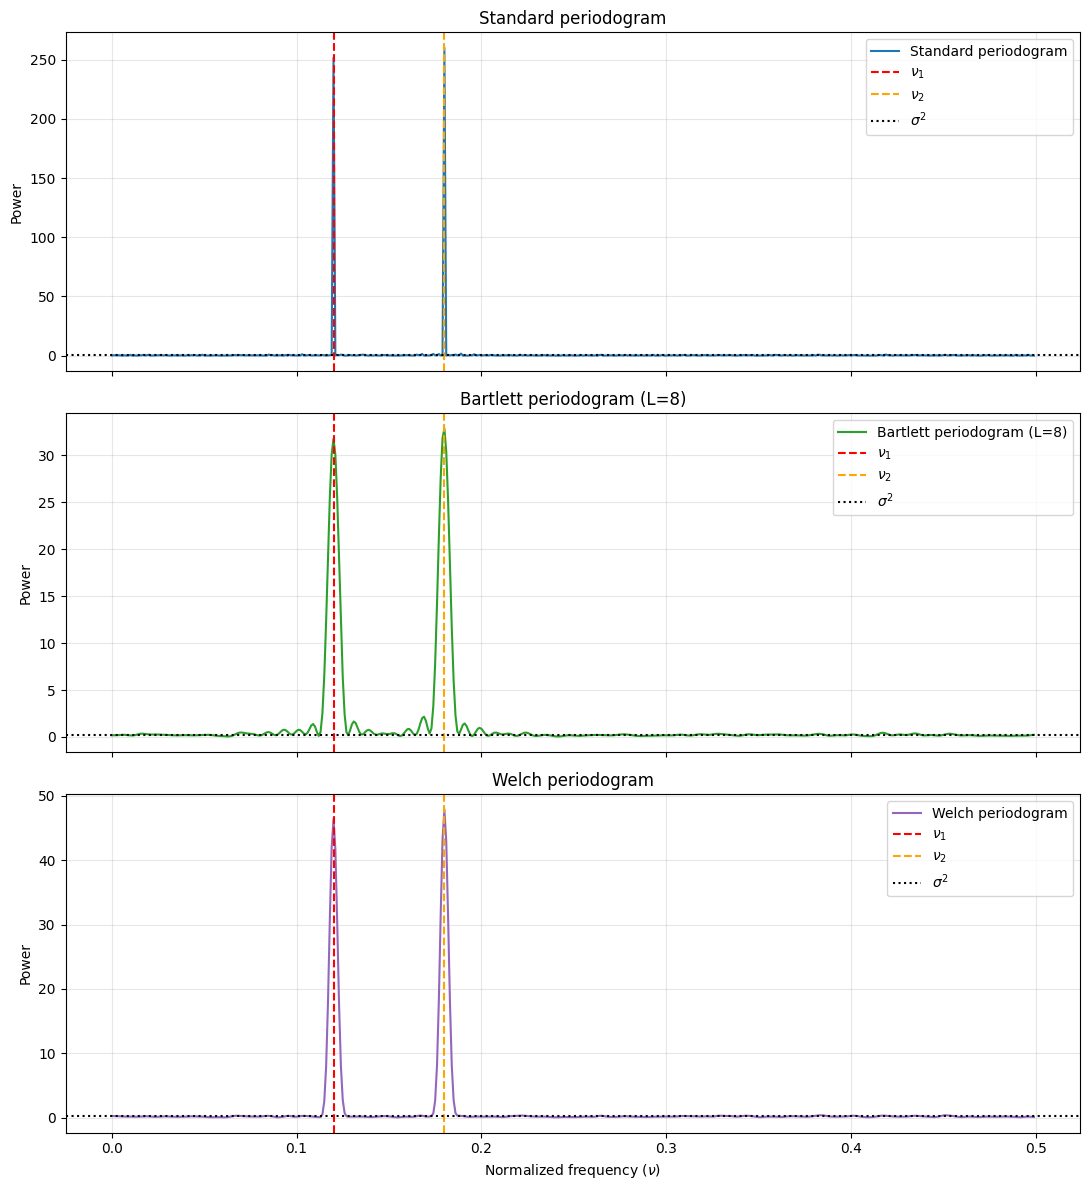

In [11]:
# Parameters: K=2 sinusoids, same amplitude=1, zero phases
N = 1024
nu_1 = 0.12
nu_2 = 0.18
sigma2 = 0.2
np.random.seed(42)

# Synthesize signal directly with normalized frequencies (nu in [0, 0.5])
n = np.arange(N)
signal_sinus = np.cos(2 * np.pi * nu_1 * n) + np.cos(2 * np.pi * nu_2 * n)
signal_sinus += np.random.normal(0, np.sqrt(sigma2), N)

# Frequency grid and periodogram estimators
nu_values = np.arange(0, 0.5, 0.001)
std_func = periodogram(signal_sinus, 'standard')
bar_func = periodogram(signal_sinus, 'bartlett', bartlett_L=8)
wel_func = periodogram(signal_sinus, 'welch')

p_std_sinus = np.array([std_func(nu) for nu in nu_values])
p_bar_sinus = np.array([bar_func(nu) for nu in nu_values])
p_wel_sinus = np.array([wel_func(nu) for nu in nu_values])

# Display periodograms with required reference lines
fig, axs = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

plots = [
    (p_std_sinus, 'Standard periodogram', 'tab:blue'),
    (p_bar_sinus, 'Bartlett periodogram (L=8)', 'tab:green'),
    (p_wel_sinus, 'Welch periodogram', 'tab:purple')
]

for ax, (p, title, color) in zip(axs, plots):
    ax.plot(nu_values, p, color=color, linewidth=1.5, label=title)
    ax.axvline(nu_1, color='red', linestyle='--', linewidth=1.5, label=r'$\nu_1$')
    ax.axvline(nu_2, color='orange', linestyle='--', linewidth=1.5, label=r'$\nu_2$')
    ax.axhline(sigma2, color='black', linestyle=':', linewidth=1.5, label=r'$\sigma^2$')
    ax.set_ylabel('Power')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

axs[-1].set_xlabel('Normalized frequency ($\\nu$)')
plt.tight_layout()
plt.show()

3. Compare the resolution of the various periodograms, by varying the difference $\Delta \nu = |\nu _1 − \nu _2|$
between both frequencies, as well as the signal-to-noise ratio (SNR) in dB.

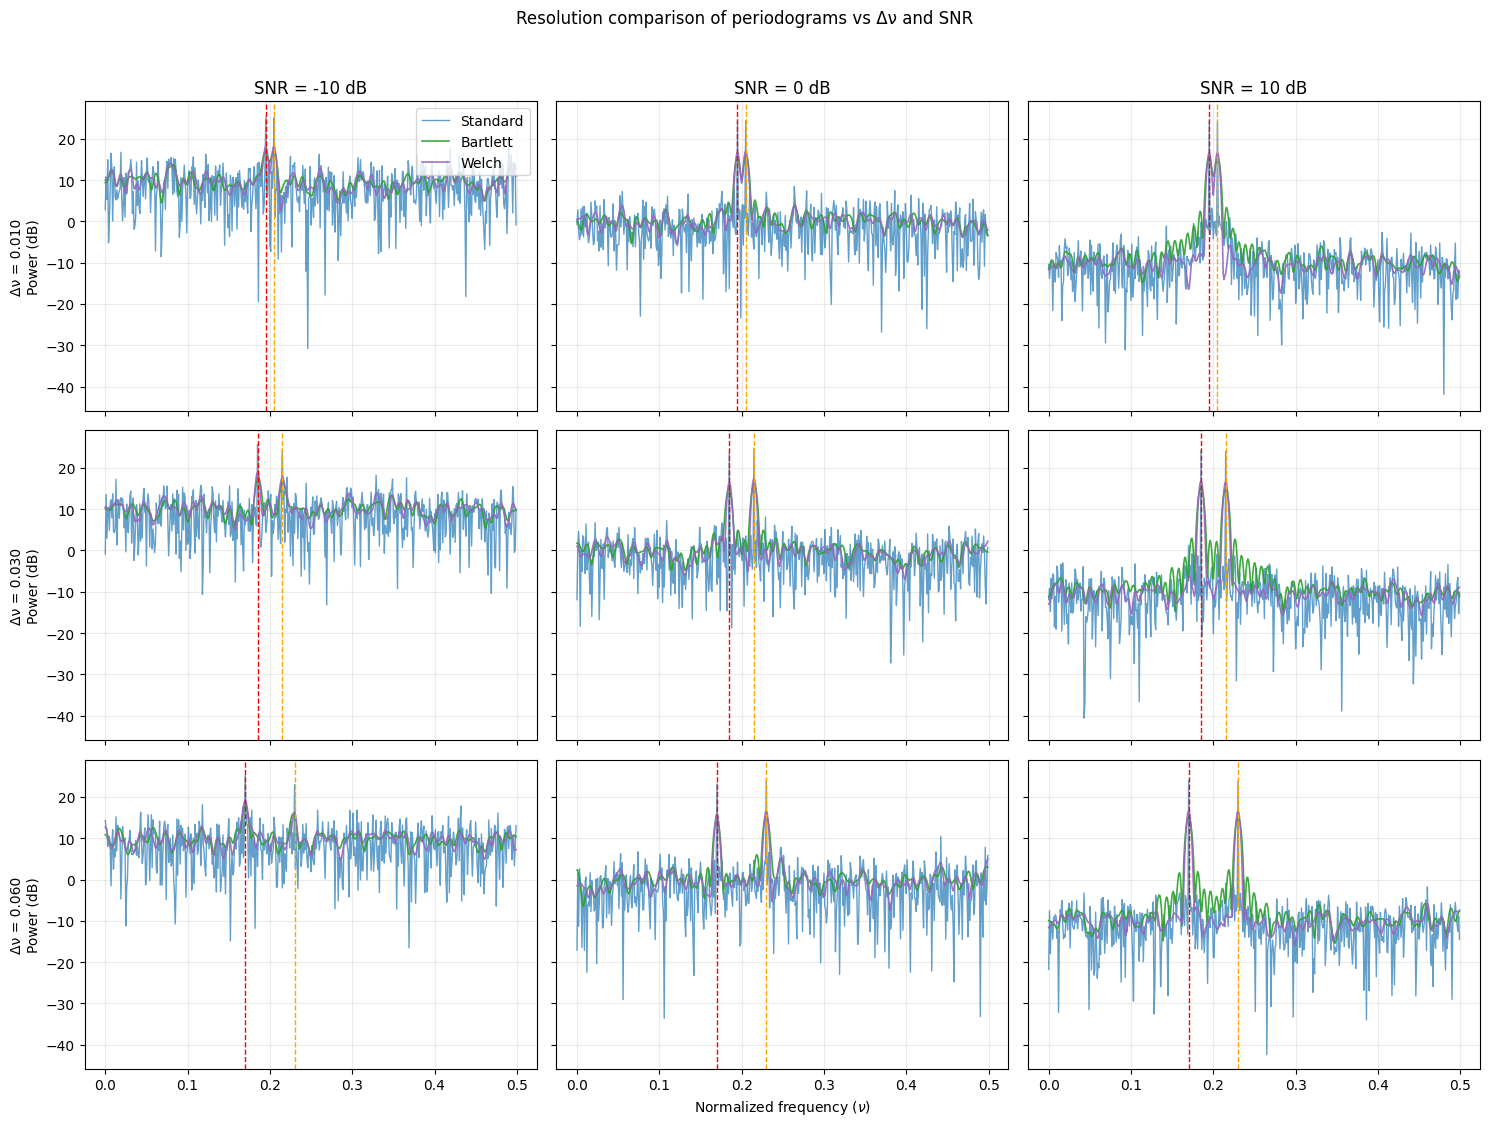

In [12]:
# Compare resolution vs frequency gap Δν and SNR for standard/Bartlett/Welch
N = 1024
nu_center = 0.20
delta_nu_values = [0.010, 0.030, 0.060]
snr_db_values = [-10, 0, 10]
nu_values = np.arange(0, 0.5, 0.001)
eps = 1e-12

# Synthesis settings: K=2, amplitudes=1, phases=0
A1, A2 = 1.0, 1.0
phi1, phi2 = 0.0, 0.0
n = np.arange(N)

fig, axs = plt.subplots(len(delta_nu_values), len(snr_db_values), figsize=(15, 11), sharex=True, sharey=True)

for i, delta_nu in enumerate(delta_nu_values):
    nu_1 = nu_center - delta_nu / 2
    nu_2 = nu_center + delta_nu / 2

    # Clean 2-tone signal and corresponding noise power from target SNR
    signal_clean = A1 * np.cos(2 * np.pi * nu_1 * n + phi1) + A2 * np.cos(2 * np.pi * nu_2 * n + phi2)
    signal_power = np.mean(signal_clean**2)

    for j, snr_db in enumerate(snr_db_values):
        sigma2 = signal_power / (10**(snr_db / 10))
        rng = np.random.default_rng(1000 + 100 * i + j)
        noise = rng.normal(0, np.sqrt(sigma2), N)
        signal_sinus = signal_clean + noise

        std_func = periodogram(signal_sinus, 'standard')
        bar_func = periodogram(signal_sinus, 'bartlett', bartlett_L=8)
        wel_func = periodogram(signal_sinus, 'welch')

        p_std = np.array([std_func(nu) for nu in nu_values])
        p_bar = np.array([bar_func(nu) for nu in nu_values])
        p_wel = np.array([wel_func(nu) for nu in nu_values])

        p_std_db = 10 * np.log10(p_std + eps)
        p_bar_db = 10 * np.log10(p_bar + eps)
        p_wel_db = 10 * np.log10(p_wel + eps)

        ax = axs[i, j]
        ax.plot(nu_values, p_std_db, color='tab:blue', alpha=0.7, linewidth=1.0, label='Standard')
        ax.plot(nu_values, p_bar_db, color='tab:green', alpha=0.9, linewidth=1.2, label='Bartlett')
        ax.plot(nu_values, p_wel_db, color='tab:purple', alpha=0.9, linewidth=1.2, label='Welch')
        ax.axvline(nu_1, color='red', linestyle='--', linewidth=1.0)
        ax.axvline(nu_2, color='orange', linestyle='--', linewidth=1.0)

        if i == 0:
            ax.set_title(f'SNR = {snr_db} dB')
        if j == 0:
            ax.set_ylabel(f'Δν = {delta_nu:.3f}\nPower (dB)')
        ax.grid(True, alpha=0.25)

axs[-1, 1].set_xlabel('Normalized frequency ($\\nu$)')
axs[0, 0].legend(loc='upper right')
plt.suptitle('Resolution comparison of periodograms vs Δν and SNR', y=1.02)
plt.tight_layout()
plt.show()

**Answer :**

When $\Delta\nu$ decreases, the two spectral peaks get closer and eventually merge, so resolution degrades for all estimators. For a fixed $\Delta\nu$, lowering SNR increases noise fluctuations and makes separation harder. The standard periodogram has sharper peaks but strong variance (noisy curves), while Bartlett and Welch are smoother (lower variance) but can lose resolution for very small $\Delta\nu$ due to averaging/windowing.

### 2.3 Parametric estimation : linear prediction

4. Estimate a fourth order AR model using the linear prediction method.

In [13]:
# Q4 - Estimate a 4th-order AR model with linear prediction (LPC)
N = 1024
nu_1 = 0.12
nu_2 = 0.18
snr_db = 10
A1, A2 = 1.0, 1.0
phi1, phi2 = 0.0, 0.0

n = np.arange(N)
signal_clean = A1 * np.cos(2 * np.pi * nu_1 * n + phi1) + A2 * np.cos(2 * np.pi * nu_2 * n + phi2)
signal_power = np.mean(signal_clean**2)
sigma2 = signal_power / (10**(snr_db / 10))

rng = np.random.default_rng(2026)
noise = rng.normal(0, np.sqrt(sigma2), N)
signal_lp = signal_clean + noise

# AR(4) estimation using linear prediction
ar_order = 4
ar4_coeffs = librosa.lpc(signal_lp, order=ar_order)
residual_ar4 = scipy.signal.lfilter(ar4_coeffs, [1], signal_lp)
sigma2_ar4 = np.var(residual_ar4)

print(f"Estimated AR model order: {ar_order}")
print(f"Estimated AR coefficients (A(z)=1+a1 z^-1+...+a4 z^-4):\n{ar4_coeffs}")
print(f"Estimated innovation variance: {sigma2_ar4:.4f}")
print(f"True noise variance: {sigma2:.4f}")

Estimated AR model order: 4
Estimated AR coefficients (A(z)=1+a1 z^-1+...+a4 z^-4):
[ 1.         -0.69815593  0.4583164   0.31605628 -0.02008796]
Estimated innovation variance: 0.3240
True noise variance: 0.1003


5. Superimpose the estimated AR model with the previous figures, always by varying the gap $\Delta \nu$, as
well as the SNR in dB. Comment on the results in terms of resolution.

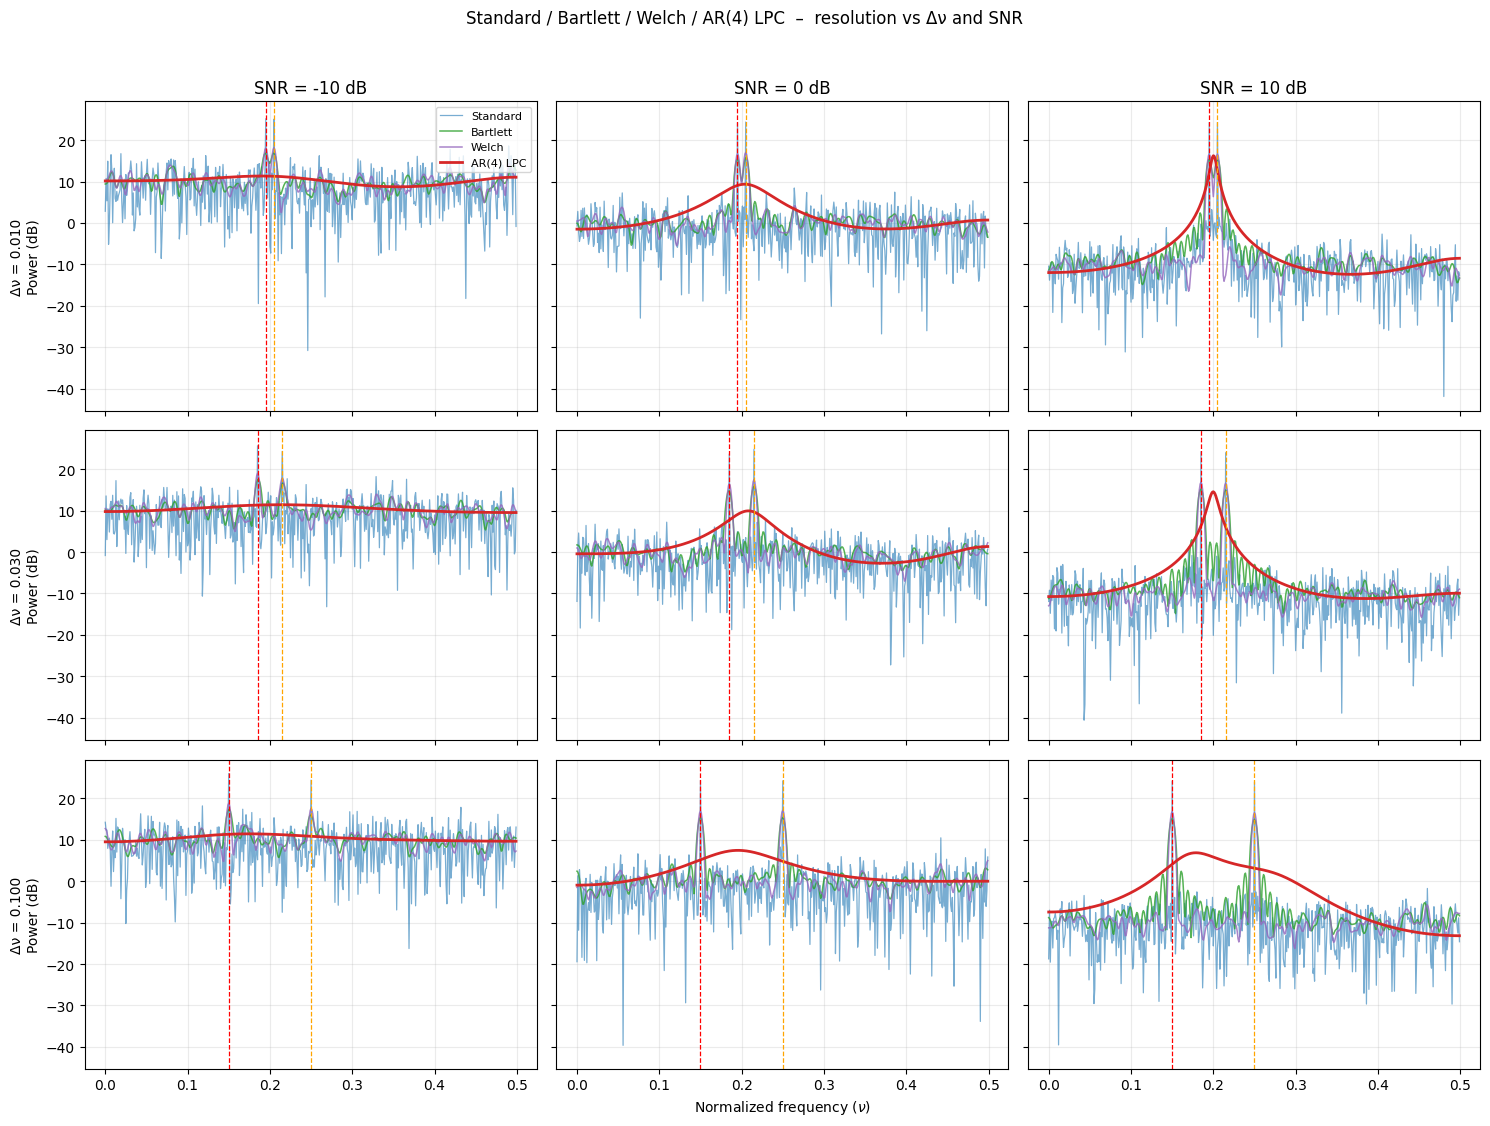

In [14]:

# Q5 – Same sweep as Q3 but with AR(4) LPC envelope superimposed
N = 1024
nu_center = 0.20
delta_nu_values = [0.010, 0.030, 0.1]
snr_db_values   = [-10, 0, 10]
nu_values = np.arange(0, 0.5, 0.001)
eps = 1e-12
ar_order = 4

A1, A2 = 1.0, 1.0
phi1, phi2 = 0.0, 0.0
n = np.arange(N)

fig, axs = plt.subplots(len(delta_nu_values), len(snr_db_values),
                        figsize=(15, 11), sharex=True, sharey=True)

k_ar = np.arange(ar_order + 1)   # index vector for AR transfer function

for i, delta_nu in enumerate(delta_nu_values):
    nu_1 = nu_center - delta_nu / 2
    nu_2 = nu_center + delta_nu / 2

    signal_clean = A1 * np.cos(2 * np.pi * nu_1 * n + phi1) + \
                   A2 * np.cos(2 * np.pi * nu_2 * n + phi2)
    signal_power = np.mean(signal_clean**2)

    for j, snr_db in enumerate(snr_db_values):
        sigma2  = signal_power / (10**(snr_db / 10))
        rng     = np.random.default_rng(1000 + 100 * i + j)   # same seed as Q3
        noise   = rng.normal(0, np.sqrt(sigma2), N)
        signal_s = signal_clean + noise

        # --- Non-parametric ---
        p_std = np.array([periodogram(signal_s, 'standard')(nu)            for nu in nu_values])
        p_bar = np.array([periodogram(signal_s, 'bartlett', bartlett_L=8)(nu) for nu in nu_values])
        p_wel = np.array([periodogram(signal_s, 'welch')(nu)               for nu in nu_values])

        # --- Parametric AR(4) ---
        ar_coeffs   = librosa.lpc(signal_s, order=ar_order)
        residual    = scipy.signal.lfilter(ar_coeffs, [1], signal_s)
        sigma2_hat  = np.var(residual)
        A_nu        = np.array([np.sum(ar_coeffs * np.exp(-2j * np.pi * nu * k_ar))
                                for nu in nu_values])
        p_ar4 = sigma2_hat / (np.abs(A_nu)**2 + eps)

        # --- dB conversion ---
        p_std_db = 10 * np.log10(p_std + eps)
        p_bar_db = 10 * np.log10(p_bar + eps)
        p_wel_db = 10 * np.log10(p_wel + eps)
        p_ar4_db = 10 * np.log10(p_ar4 + eps)

        ax = axs[i, j]
        ax.plot(nu_values, p_std_db, color='tab:blue',   alpha=0.6, linewidth=0.9, label='Standard')
        ax.plot(nu_values, p_bar_db, color='tab:green',  alpha=0.8, linewidth=1.1, label='Bartlett')
        ax.plot(nu_values, p_wel_db, color='tab:purple', alpha=0.8, linewidth=1.1, label='Welch')
        ax.plot(nu_values, p_ar4_db, color='tab:red',    alpha=1.0, linewidth=2.0, label='AR(4) LPC')
        ax.axvline(nu_1, color='red',    linestyle='--', linewidth=0.9)
        ax.axvline(nu_2, color='orange', linestyle='--', linewidth=0.9)

        if i == 0:
            ax.set_title(f'SNR = {snr_db} dB')
        if j == 0:
            ax.set_ylabel(f'Δν = {delta_nu:.3f}\nPower (dB)')
        ax.grid(True, alpha=0.25)

axs[-1, 1].set_xlabel('Normalized frequency ($\\nu$)')
axs[0, 0].legend(loc='upper right', fontsize=8)
plt.suptitle('Standard / Bartlett / Welch / AR(4) LPC  –  resolution vs Δν and SNR', y=1.02)
plt.tight_layout()
plt.show()


**Answer :**

The AR(4) LPC envelope (red) is the smoothest curve but has **worse frequency resolution** than all non-parametric methods for closely-spaced sinusoids. This is because a low-order rational model cannot capture two narrow peaks that are close together — it approximates them with a single broad hump.

Concretely from the plots:

- **Δν = 0.010 (top row):** AR(4) shows one merged broad peak at every SNR. Even the noisy standard periodogram can hint at the correct spike locations at SNR = 10 dB.
- **Δν = 0.030 (middle row):** AR(4) still merges the two lines into a wide bump. Bartlett and Welch begin to show a shoulder at SNR = 10 dB, while the standard periodogram clearly spikes at both frequencies.
- **Δν = 0.100 (bottom row):** AR(4) finally separates the two peaks at SNR = 0 and 10 dB, but produces a flat uninformative envelope at SNR = −10 dB where non-parametric methods still show spikes near the true frequencies.
- **SNR = −10 dB (left column):** All methods degrade significantly. The AR(4) curve is nearly flat and carries almost no frequency information.

In summary, the LPC model trades resolution for smoothness: it works well when the underlying spectral peaks are widely separated and the SNR is high, but it is **outperformed in resolution** by the standard periodogram (and even by Bartlett/Welch) when $\Delta\nu$ is small.

### 2.4 Parametric estimation : Capon estimator

6. Code a function that implements the Capon estimator

**Answer :**

See the code added to the $\texttt{periodogram}$ function with the flag $\texttt{estimator = 'capon'}$

7. Compare the resolution of this method with the two previous methods, always by varying $\Delta \nu$, as
well as the SNR in dB.


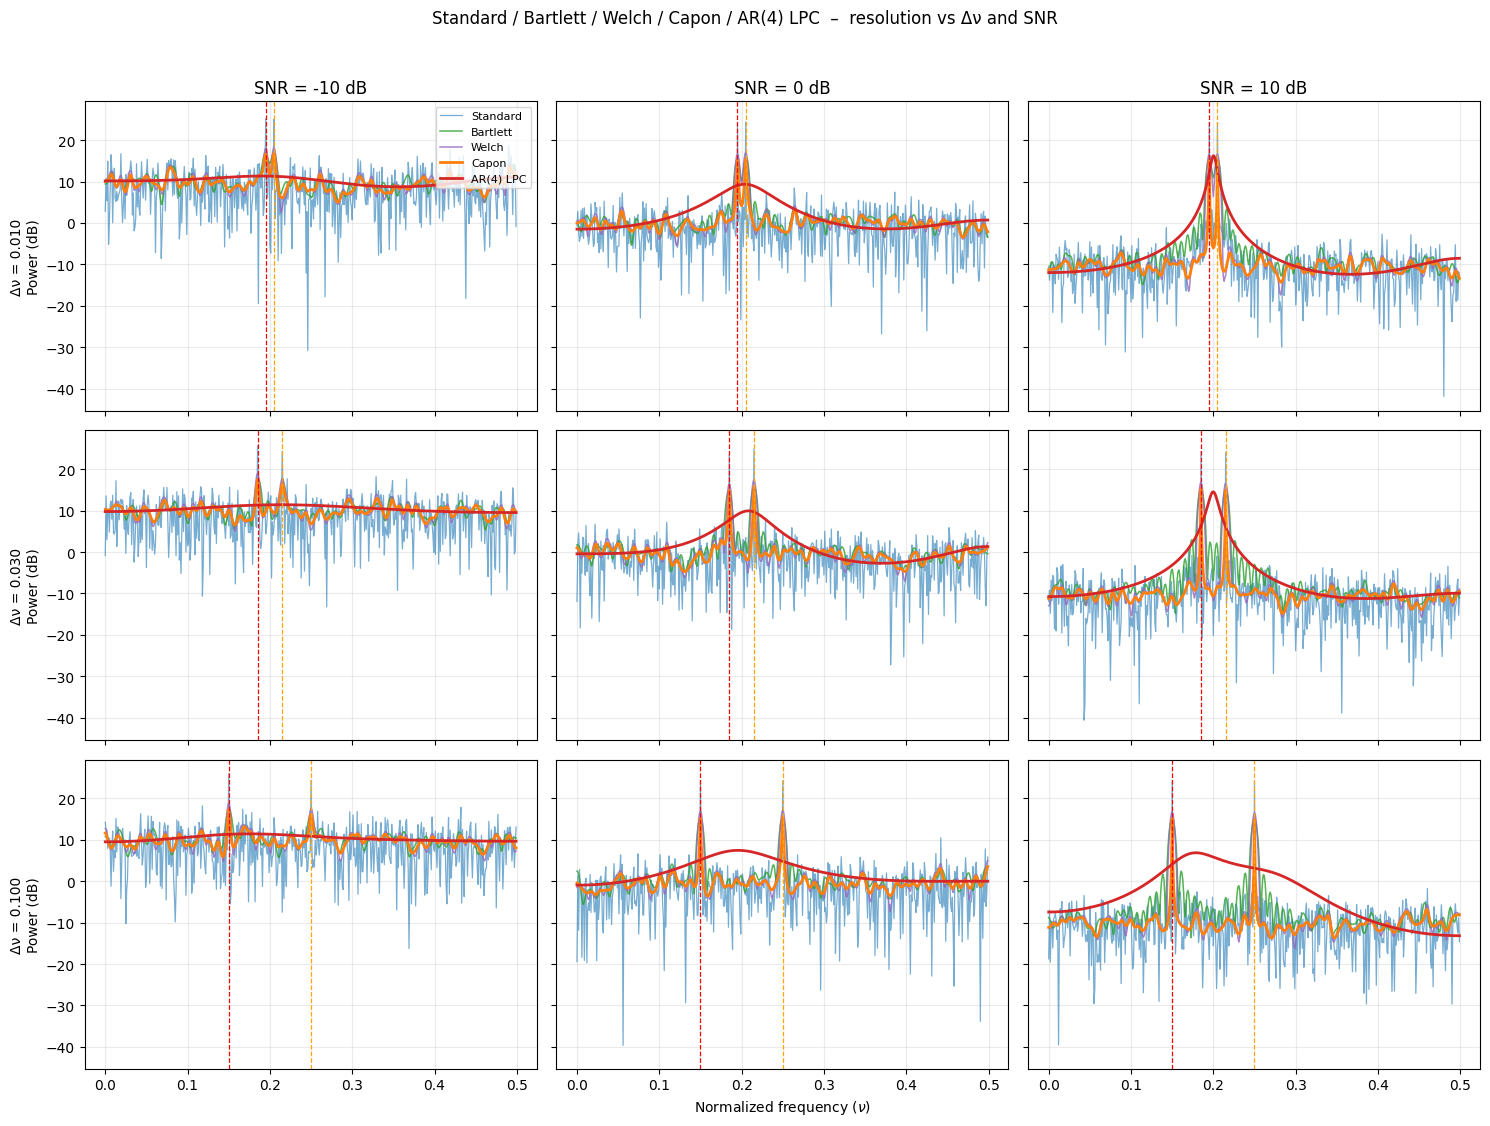

In [ ]:

# Q6 – Same sweep as Q-5
N = 1024
nu_center = 0.20
delta_nu_values = [0.010, 0.030, 0.1]
snr_db_values   = [-10, 0, 10]
nu_values = np.arange(0, 0.5, 0.001)
eps = 1e-12
ar_order = 4

A1, A2 = 1.0, 1.0
phi1, phi2 = 0.0, 0.0
n = np.arange(N)

fig, axs = plt.subplots(len(delta_nu_values), len(snr_db_values),
                        figsize=(15, 11), sharex=True, sharey=True)

k_ar = np.arange(ar_order + 1)   # index vector for AR transfer function

for i, delta_nu in enumerate(delta_nu_values):
    nu_1 = nu_center - delta_nu / 2
    nu_2 = nu_center + delta_nu / 2

    signal_clean = A1 * np.cos(2 * np.pi * nu_1 * n + phi1) + \
                   A2 * np.cos(2 * np.pi * nu_2 * n + phi2)
    signal_power = np.mean(signal_clean**2)

    for j, snr_db in enumerate(snr_db_values):
        sigma2  = signal_power / (10**(snr_db / 10))
        rng     = np.random.default_rng(1000 + 100 * i + j)   # same seed as Q3
        noise   = rng.normal(0, np.sqrt(sigma2), N)
        signal_s = signal_clean + noise

        # --- Non-parametric ---
        p_std = np.array([periodogram(signal_s, 'standard')(nu) for nu in nu_values])
        p_bar = np.array([periodogram(signal_s, 'bartlett', bartlett_L=8)(nu) for nu in nu_values])
        p_wel = np.array([periodogram(signal_s, 'welch')(nu) for nu in nu_values])
        p_cap = np.array([periodogram(signal_s, 'capon')(nu) for nu in nu_values])

        # --- Parametric AR(4) ---
        ar_coeffs   = librosa.lpc(signal_s, order=ar_order)
        residual    = scipy.signal.lfilter(ar_coeffs, [1], signal_s)
        sigma2_hat  = np.var(residual)
        A_nu        = np.array([np.sum(ar_coeffs * np.exp(-2j * np.pi * nu * k_ar))
                                for nu in nu_values])
        p_ar4 = sigma2_hat / (np.abs(A_nu)**2 + eps)

        # --- dB conversion ---
        p_std_db = 10 * np.log10(p_std + eps)
        p_bar_db = 10 * np.log10(p_bar + eps)
        p_wel_db = 10 * np.log10(p_wel + eps)
        p_ar4_db = 10 * np.log10(p_ar4 + eps)
        p_cap_db = 10 * np.log10(p_cap + eps)

        ax = axs[i, j]
        ax.plot(nu_values, p_std_db, color='tab:blue',   alpha=0.6, linewidth=0.9, label='Standard')
        ax.plot(nu_values, p_bar_db, color='tab:green',  alpha=0.8, linewidth=1.1, label='Bartlett')
        ax.plot(nu_values, p_wel_db, color='tab:purple', alpha=0.8, linewidth=1.1, label='Welch')
        ax.plot(nu_values, p_cap_db, color='tab:orange', alpha=1.0, linewidth=2.0, label='Capon')
        ax.plot(nu_values, p_ar4_db, color='tab:red',    alpha=1.0, linewidth=2.0, label='AR(4) LPC')
        ax.axvline(nu_1, color='red',    linestyle='--', linewidth=0.9)
        ax.axvline(nu_2, color='orange', linestyle='--', linewidth=0.9)

        if i == 0:
            ax.set_title(f'SNR = {snr_db} dB')
        if j == 0:
            ax.set_ylabel(f'Δν = {delta_nu:.3f}\nPower (dB)')
        ax.grid(True, alpha=0.25)

axs[-1, 1].set_xlabel('Normalized frequency ($\\nu$)')
axs[0, 0].legend(loc='upper right', fontsize=8)
plt.suptitle('Standard / Bartlett / Welch / Capon / AR(4) LPC  –  resolution vs Δν and SNR', y=1.02)
plt.tight_layout()
plt.show()


## 3. Autoregressive-moving-average process

### 3.1 Synthesis

1. Code a function that synthesizes an autoregressive-moving-average (ARMA) process of length N,
defined by its AR and MA coefficients and by the innovation variance $\sigma^2$

In [ ]:
def synthetize_arma(ar_coeffs, ma_coeffs, N, sigma=1.0):
    noise = np.random.normal(0, sigma, N)
    signal = scipy.signal.lfilter(ma_coeffs, ar_coeffs, noise)
    return signal

### 3.2 Non-parametric estimation : periodogram

2. Display the periodograms obtained with the different methods, in the case of an ARMA process
of order (1, 1) whose parameters can be chosen by hand. We will superimpose in each case the
periodogram with the known PSD of the ARMA process.

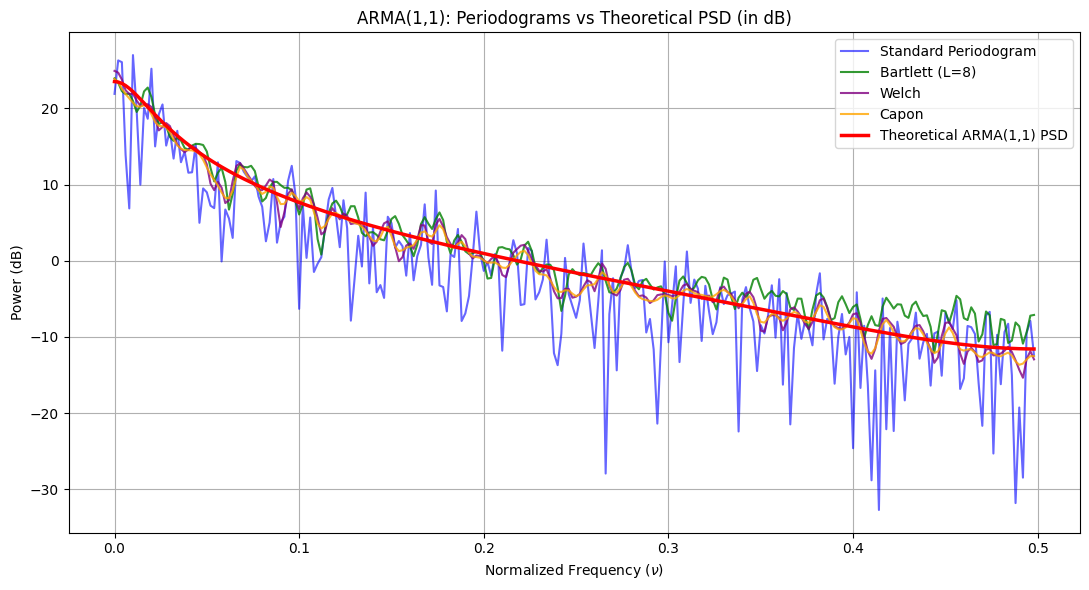

In [41]:

# ARMA(1,1) parameters: x[n] = 0.9 x[n-1] + e[n] + 0.5 e[n-1], σ²=1
N = 1024
a_ar = 0.9
b_ma = 0.5
sigma2 = 1.0
np.random.seed(42)

signal_arma_11 = synthetize_arma([1.0, -a_ar], [1.0, b_ma], N, np.sqrt(sigma2))

nu_values = np.arange(0, 0.5, 0.002)
eps = 1e-12

# Theoretical PSD of ARMA(1,1)
theoretical_psd = sigma2 * np.abs(1 + b_ma * np.exp(-2j * np.pi * nu_values))**2 \
                         / np.abs(1 - a_ar * np.exp(-2j * np.pi * nu_values))**2
theoretical_psd_db = 10 * np.log10(theoretical_psd)

# Non-parametric estimators
std_func = periodogram(signal_arma_11, 'standard')
bar_func = periodogram(signal_arma_11, 'bartlett', bartlett_L=8)
wel_func = periodogram(signal_arma_11, 'welch')
cap_func = periodogram(signal_arma_11, 'capon')

p_std_db = 10 * np.log10(np.array([std_func(nu) for nu in nu_values]) + eps)
p_bar_db = 10 * np.log10(np.array([bar_func(nu) for nu in nu_values]) + eps)
p_wel_db = 10 * np.log10(np.array([wel_func(nu) for nu in nu_values]) + eps)
p_cap_db = 10 * np.log10(np.array([cap_func(nu) for nu in nu_values]) + eps)

plt.figure(figsize=(11, 6))
plt.plot(nu_values, p_std_db, color='blue', alpha=0.6, label='Standard Periodogram')
plt.plot(nu_values, p_bar_db, color='green', alpha=0.8, label='Bartlett (L=8)')
plt.plot(nu_values, p_wel_db, color='purple', alpha=0.8, label='Welch')
plt.plot(nu_values, p_cap_db, color='orange', alpha=0.8, label='Capon')
plt.plot(nu_values, theoretical_psd_db, 'r-', linewidth=2.5, label='Theoretical ARMA(1,1) PSD')
plt.title('ARMA(1,1): Periodograms vs Theoretical PSD (in dB)')
plt.xlabel('Normalized Frequency ($\\nu$)')
plt.ylabel('Power (dB)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


3. Compare these different estimators in terms of bias and variance.

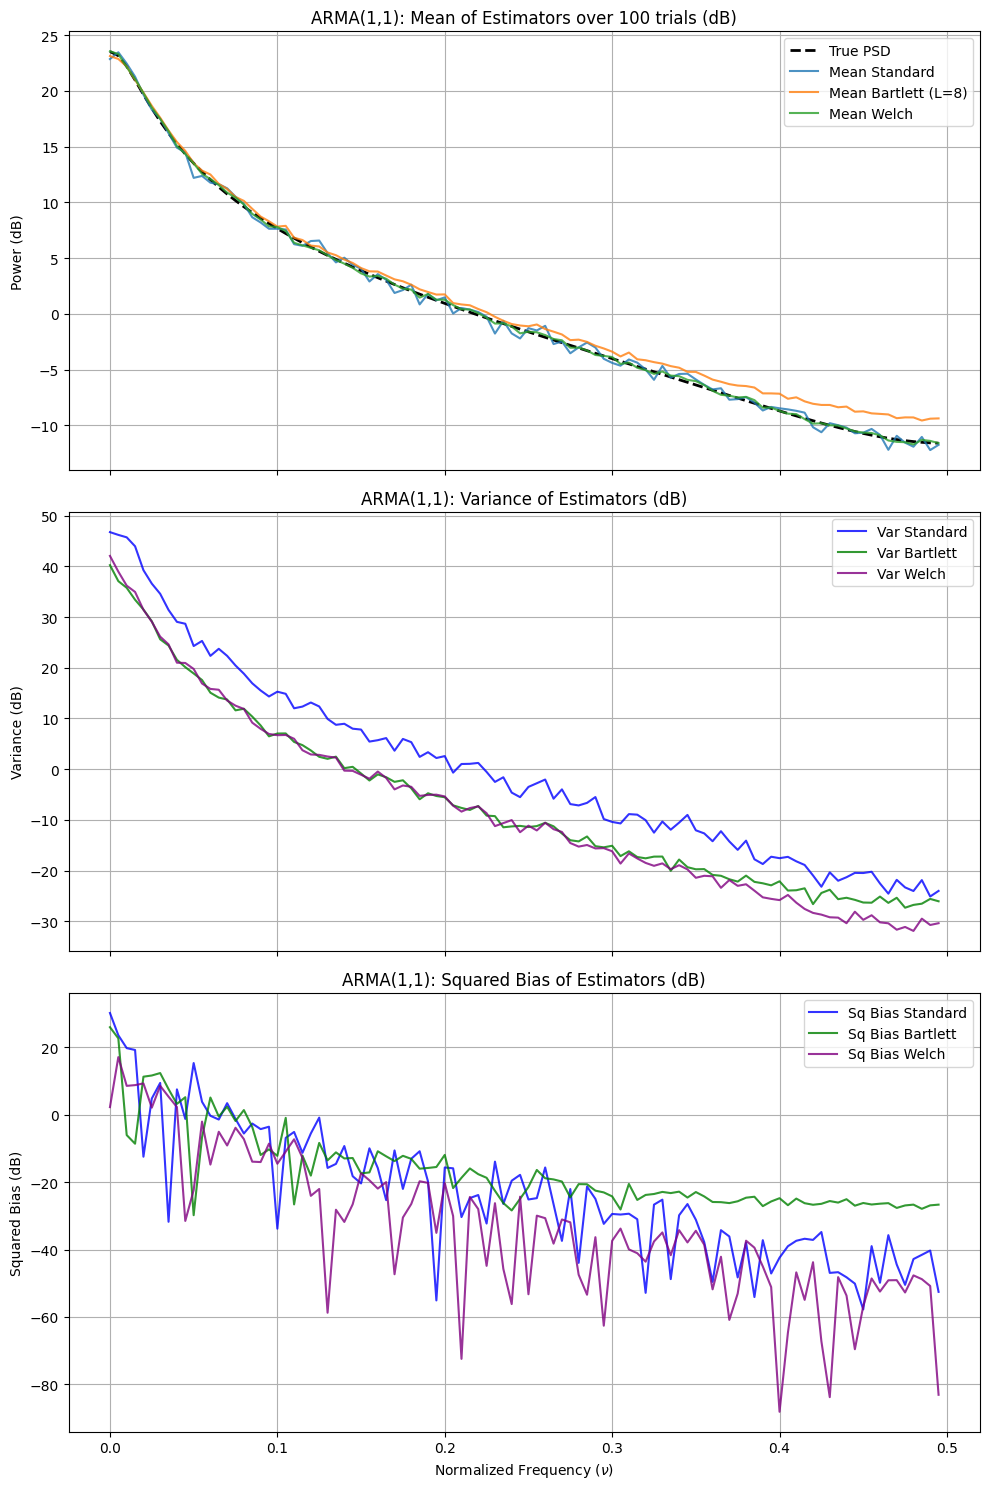

In [43]:

# Bias and variance comparison for ARMA(1,1) estimators
N = 1024
a_ar = 0.9
b_ma = 0.5
sigma2 = 1.0
num_trials = 100
nu_values = np.arange(0, 0.5, 0.005)
eps = 1e-12

# Theoretical PSD of ARMA(1,1)
theoretical_psd = sigma2 * np.abs(1 + b_ma * np.exp(-2j * np.pi * nu_values))**2 \
                         / np.abs(1 - a_ar * np.exp(-2j * np.pi * nu_values))**2

std_estimates = np.zeros((num_trials, len(nu_values)))
bar_estimates = np.zeros((num_trials, len(nu_values)))
wel_estimates = np.zeros((num_trials, len(nu_values)))

np.random.seed(42)

for k in range(num_trials):
    sig = synthetize_arma([1.0, -a_ar], [1.0, b_ma], N, np.sqrt(sigma2))

    std_func = periodogram(sig, 'standard')
    bar_func = periodogram(sig, 'bartlett', bartlett_L=8)
    wel_func = periodogram(sig, 'welch')

    std_estimates[k, :] = [std_func(nu) for nu in nu_values]
    bar_estimates[k, :] = [bar_func(nu) for nu in nu_values]
    wel_estimates[k, :] = [wel_func(nu) for nu in nu_values]

mean_std = np.mean(std_estimates, axis=0)
mean_bar = np.mean(bar_estimates, axis=0)
mean_wel = np.mean(wel_estimates, axis=0)

var_std = np.var(std_estimates, axis=0)
var_bar = np.var(bar_estimates, axis=0)
var_wel = np.var(wel_estimates, axis=0)

sq_bias_std = (mean_std - theoretical_psd)**2
sq_bias_bar = (mean_bar - theoretical_psd)**2
sq_bias_wel = (mean_wel - theoretical_psd)**2

fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

axs[0].plot(nu_values, 10*np.log10(theoretical_psd), 'k--', label='True PSD', linewidth=2)
axs[0].plot(nu_values, 10*np.log10(mean_std), label='Mean Standard', alpha=0.8)
axs[0].plot(nu_values, 10*np.log10(mean_bar), label='Mean Bartlett (L=8)', alpha=0.8)
axs[0].plot(nu_values, 10*np.log10(mean_wel), label='Mean Welch', alpha=0.8)
axs[0].set_title('ARMA(1,1): Mean of Estimators over 100 trials (dB)')
axs[0].set_ylabel('Power (dB)')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(nu_values, 10*np.log10(var_std + eps), label='Var Standard', color='blue', alpha=0.8)
axs[1].plot(nu_values, 10*np.log10(var_bar + eps), label='Var Bartlett', color='green', alpha=0.8)
axs[1].plot(nu_values, 10*np.log10(var_wel + eps), label='Var Welch', color='purple', alpha=0.8)
axs[1].set_title('ARMA(1,1): Variance of Estimators (dB)')
axs[1].set_ylabel('Variance (dB)')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(nu_values, 10*np.log10(sq_bias_std + eps), label='Sq Bias Standard', color='blue', alpha=0.8)
axs[2].plot(nu_values, 10*np.log10(sq_bias_bar + eps), label='Sq Bias Bartlett', color='green', alpha=0.8)
axs[2].plot(nu_values, 10*np.log10(sq_bias_wel + eps), label='Sq Bias Welch', color='purple', alpha=0.8)
axs[2].set_title('ARMA(1,1): Squared Bias of Estimators (dB)')
axs[2].set_xlabel('Normalized Frequency ($\\nu$)')
axs[2].set_ylabel('Squared Bias (dB)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

### 3.3 Parametric estimation : Durbin method

4. Code a function that implements the Durbin method (estimation of the AR part by shifting the
autocorrelation, estimation of the MA part via a long AR)

**Answer :**

See the code added to the $\texttt{periodogram}$ function with the flag $\texttt{estimator = 'durbin'}$

5. Superimpose the spectral envelope of the estimated ARMA model with that of the exact ARMA
model and with the periodogram. Comment.

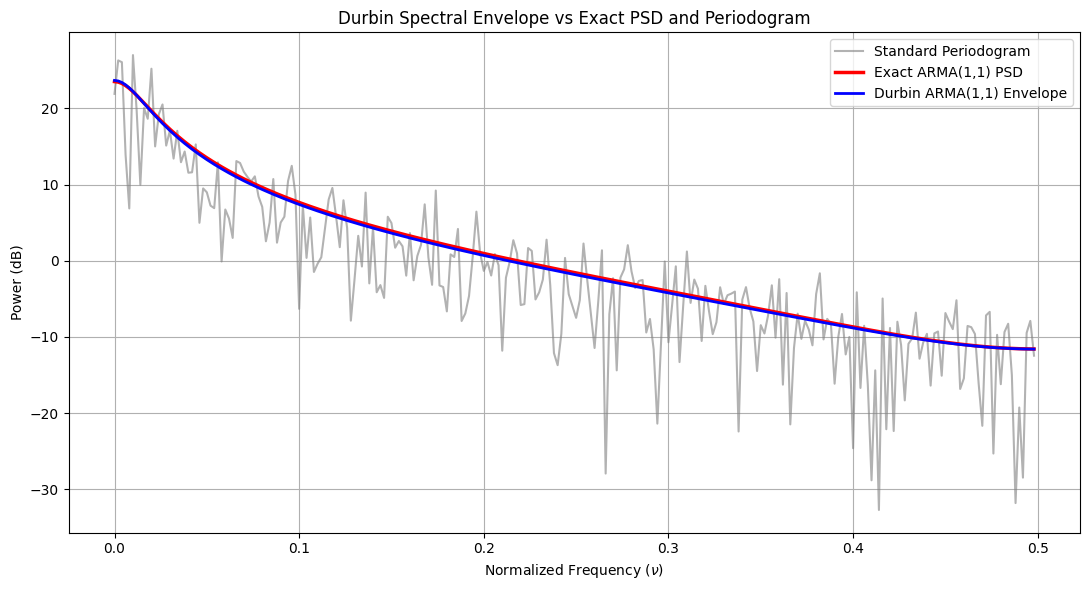

In [45]:

# Q5 – Durbin ARMA(1,1) spectral envelope vs exact PSD and periodogram
N = 1024
a_ar = 0.9
b_ma = 0.5
sigma2 = 1.0
np.random.seed(42)

signal_arma = synthetize_arma([1.0, -a_ar], [1.0, b_ma], N, np.sqrt(sigma2))

nu_values = np.arange(0, 0.5, 0.002)
eps = 1e-12

# Theoretical PSD of ARMA(1,1)
theoretical_psd = sigma2 * np.abs(1 + b_ma * np.exp(-2j * np.pi * nu_values))**2 \
                         / np.abs(1 - a_ar * np.exp(-2j * np.pi * nu_values))**2
theoretical_psd_db = 10 * np.log10(theoretical_psd)

# Standard periodogram
std_func = periodogram(signal_arma, 'standard')
p_std_db = 10 * np.log10(np.array([std_func(nu) for nu in nu_values]) + eps)

# Durbin ARMA(1,1) spectral envelope
durbin_func = periodogram(signal_arma, 'durbin', durbin_p=1, durbin_q=1)
p_durbin_db = 10 * np.log10(np.array([durbin_func(nu) for nu in nu_values]) + eps)

plt.figure(figsize=(11, 6))
plt.plot(nu_values, p_std_db, color='gray', alpha=0.6, label='Standard Periodogram')
plt.plot(nu_values, theoretical_psd_db, 'r-', linewidth=2.5, label='Exact ARMA(1,1) PSD')
plt.plot(nu_values, p_durbin_db, 'b-', linewidth=2.0, label='Durbin ARMA(1,1) Envelope')
plt.title('Durbin Spectral Envelope vs Exact PSD and Periodogram')
plt.xlabel('Normalized Frequency ($\\nu$)')
plt.ylabel('Power (dB)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Answer :**

The Durbin spectral envelope tracks the exact PSD closely and smoothly, unlike the highly variable standard periodogram, since it exploits the known ARMA structure and estimates only a few parameters (one AR, one MA coefficient + innovation variance).

### 3.4 Application to speech signals

6. Apply the above methods to a nasal vowel sound (such as ’in’ for example, that we will be able to
extract from file an_in_on.wav, downloadable on the IP Paris Moodle of 4AI03), and superimpose the estimated spectra.

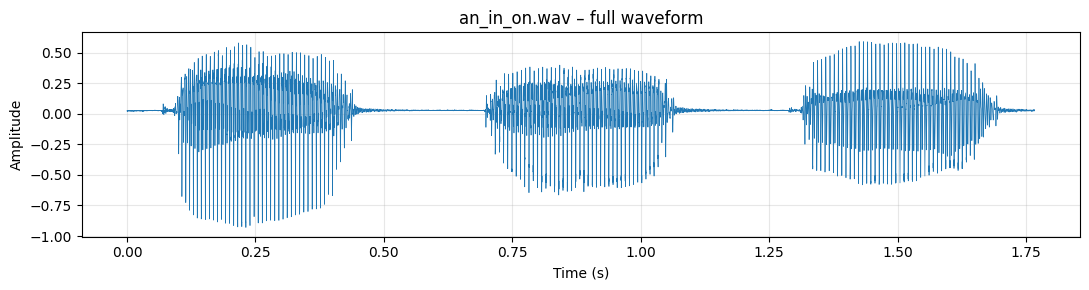

Sampling rate: 16000 Hz | Duration: 1.77 s


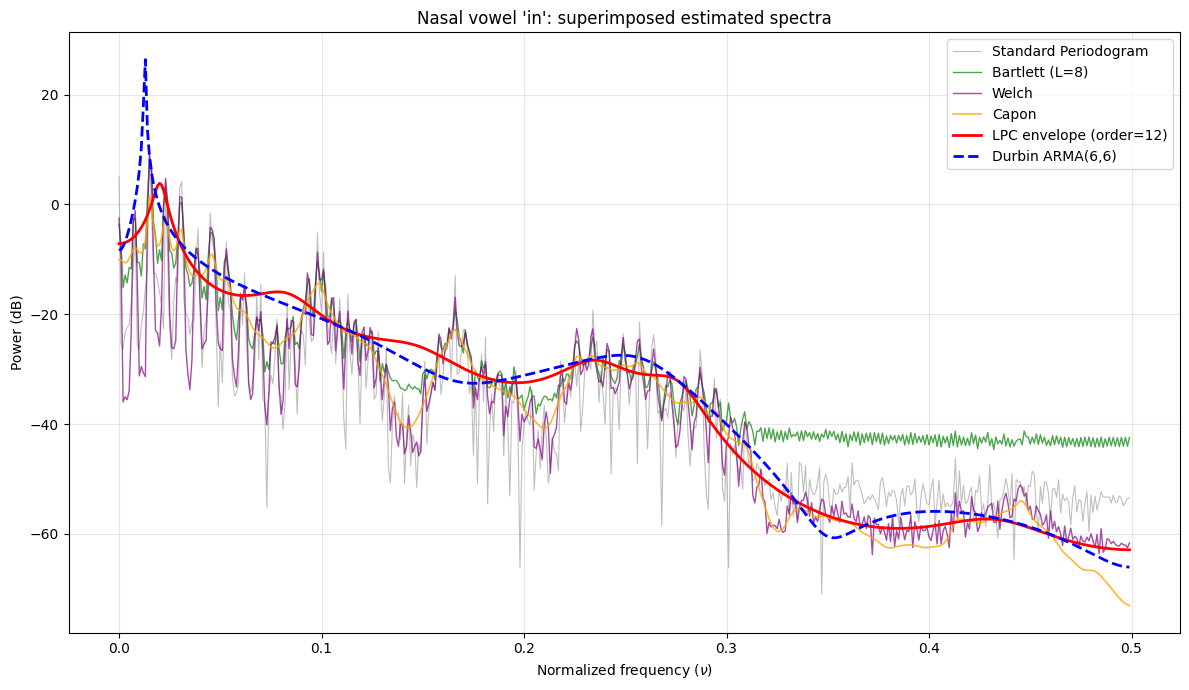

Segment length: 0.250 s (4000 samples)


In [49]:
# Q6 – Apply all methods to nasal vowel 'in' from an_in_on.wav
audio_path = "an_in_on.wav"
signal_nasal, sr = sf.read(audio_path)
if signal_nasal.ndim > 1:
    signal_nasal = signal_nasal.mean(axis=1)

# Plot the full waveform to identify the 'in' segment
plt.figure(figsize=(11, 3))
t_axis = np.arange(len(signal_nasal)) / sr
plt.plot(t_axis, signal_nasal, linewidth=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('an_in_on.wav – full waveform')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Sampling rate: {sr} Hz | Duration: {len(signal_nasal)/sr:.2f} s")

# Extract approximately the 'in' segment (middle nasal vowel)
# Adjust start/end times after inspecting the waveform above
start_time = 0.75
end_time = 1.0
y_in = signal_nasal[int(start_time * sr):int(end_time * sr)]

# Frequency grid
nu_values = np.arange(0, 0.5, 0.001)
eps = 1e-12

# --- Non-parametric estimators ---
std_func = periodogram(y_in, 'standard')
bar_func = periodogram(y_in, 'bartlett', bartlett_L=8)
wel_func = periodogram(y_in, 'welch')
cap_func = periodogram(y_in, 'capon')

p_std_db = 10 * np.log10(np.array([std_func(nu) for nu in nu_values]) + eps)
p_bar_db = 10 * np.log10(np.array([bar_func(nu) for nu in nu_values]) + eps)
p_wel_db = 10 * np.log10(np.array([wel_func(nu) for nu in nu_values]) + eps)
p_cap_db = 10 * np.log10(np.array([cap_func(nu) for nu in nu_values]) + eps)

# --- Parametric: LPC (AR) envelope ---
ar_order = 12
a_lpc = librosa.lpc(y_in, order=ar_order)
residu = scipy.signal.lfilter(a_lpc, [1], y_in)
var_lpc = np.var(residu)
k_ar = np.arange(ar_order + 1)
A_nu = np.array([np.sum(a_lpc * np.exp(-2j * np.pi * nu * k_ar)) for nu in nu_values])
p_lpc_db = 10 * np.log10(var_lpc / (np.abs(A_nu)**2 + eps) + eps)

# --- Parametric: Durbin ARMA envelope ---
durbin_p, durbin_q = 6, 6
durbin_func = periodogram(y_in, 'durbin', durbin_p=durbin_p, durbin_q=durbin_q)
p_durbin_db = 10 * np.log10(np.array([durbin_func(nu) for nu in nu_values]) + eps)

# --- Superimposed plot ---
plt.figure(figsize=(12, 7))
plt.plot(nu_values, p_std_db, color='gray', alpha=0.5, linewidth=0.8, label='Standard Periodogram')
plt.plot(nu_values, p_bar_db, color='green', alpha=0.7, linewidth=1.0, label='Bartlett (L=8)')
plt.plot(nu_values, p_wel_db, color='purple', alpha=0.7, linewidth=1.0, label='Welch')
plt.plot(nu_values, p_cap_db, color='orange', alpha=0.8, linewidth=1.2, label='Capon')
plt.plot(nu_values, p_lpc_db, color='red', linewidth=2.0, label=f'LPC envelope (order={ar_order})')
plt.plot(nu_values, p_durbin_db, color='blue', linewidth=2.0, linestyle='--',
         label=f'Durbin ARMA({durbin_p},{durbin_q})')
plt.title("Nasal vowel 'in': superimposed estimated spectra")
plt.xlabel('Normalized frequency ($\\nu$)')
plt.ylabel('Power (dB)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Segment length: {len(y_in)/sr:.3f} s ({len(y_in)} samples)")
